In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
from torch import nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
def get_data_loaders(data_dir,
                     batch_size,
                     train_transform,
                     test_transform,
                     shuffle=True,
                     num_workers=4,
                     pin_memory=False):
    # Load the datasets
    train_dataset = datasets.CIFAR10(
        root=data_dir, train=True,
        download=True, transform=train_transform,
    )

    test_dataset = datasets.CIFAR10(
        root=data_dir, train=False,
        download=True, transform=test_transform,
    )

    # Create loader objects
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=shuffle,
        num_workers=num_workers, pin_memory=pin_memory
    )

    test_loader = torch.utils.data.DataLoader(
        test_dataset, batch_size=batch_size, shuffle=shuffle,
        num_workers=num_workers, pin_memory=pin_memory
    )

    return (train_loader, test_loader)

    Params
    ------
    - data_dir: path directory to the dataset.
    - batch_size: how many samples per batch to load.
    - train_transform: pytorch transforms for the training set
    - test_transform: pytorch transofrms for the test set
    - num_workers: number of subprocesses to use when loading the dataset.
    - pin_memory: whether to copy tensors into CUDA pinned memory. Set it to
      True if using GPU.
    
    Returns
    -------
    - train_loader: training set iterator.
    - test_loader:  test set iterator.
    """


In [ ]:
def plot_images(images, cls_true, cls_pred=None):
    """
    Plot images with labels.
    """
    # CIFAR10 labels
    label_names = [
        'airplane',
        'automobile',
        'bird',
        'cat',
        'deer',
        'dog',
        'frog',
        'horse',
        'ship',
        'truck'
    ]

    fig, axes = plt.subplots(3, 3)

    for i, ax in enumerate(axes.flat):
        # plot img
        ax.imshow(images[i, :, :, :], interpolation='spline16')

        # show true & predicted classes
        cls_true_name = label_names[cls_true[i]]
        if cls_pred is None:
            xlabel = "{0} ({1})".format(cls_true_name, cls_true[i])
        else:
            cls_pred_name = label_names[cls_pred[i]]
            xlabel = "True: {0}\nPred: {1}".format(
                cls_true_name, cls_pred_name
            )
        ax.set_xlabel(xlabel)
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()

In [ ]:

class block(nn.Module):
    def __init__(self, filters, subsample=False):
        super().__init__()
        """
        A 2-layer residual learning building block as illustrated by Fig.2
        in "Deep Residual Learning for Image Recognition"

        Parameters:

        - filters:   int
                     the number of filters for all layers in this block

        - subsample: boolean
                     whether to subsample the input feature maps with stride 2
                     and doubling in number of filters

        Attributes:

        - shortcuts: boolean
                     When false the residual shortcut is removed
                     resulting in a 'plain' convolutional block.
        """
        # Determine subsampling
        s = 0.5 if subsample else 1.0

        # Setup layers
        self.conv1 = nn.Conv2d(int(filters*s), filters, kernel_size=3,
                               stride=int(1/s), padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(filters, track_running_stats=True)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(filters, filters, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(filters, track_running_stats=True)
        self.relu2 = nn.ReLU()

        # Shortcut downsampling
        self.downsample = nn.AvgPool2d(kernel_size=1, stride=2)

        # Initialise weights according to the method described in
        # “Delving deep into rectifiers: Surpassing human-level performance on ImageNet
        # classification” - He, K. et al. (2015)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def shortcut(self, z, x):
        """
        Implements parameter free shortcut connection by identity mapping.
        If dimensions of input x are greater than activations then this
        is rectified by downsampling and then zero padding dimension 1
        as described by option A in paper.

        Parameters:
        - x: tensor
             the input to the block
        - z: tensor
             activations of block prior to final non-linearity
        """
        if x.shape != z.shape:
            d = self.downsample(x)
            p = torch.mul(d, 0)
            return z + torch.cat((d, p), dim=1)
        else:
            return z + x

    def forward(self, x, shortcuts=False):
        z = self.conv1(x)
        z = self.bn1(z)
        z = self.relu1(z)

        z = self.conv2(z)
        z = self.bn2(z)

        # Shortcut connection
        # This if statement is the only difference between
        # a convolutional net and a resnet!
        if shortcuts:
            z = self.shortcut(z, x)

        z = self.relu2(z)

        return z

## 🔷 Now Let’s Explain

Here is your function (cleaned):

```python
def shortcut(self, z, x):
```

**Parameters:**

| Variable | Meaning                          |
|----------|----------------------------------|
| `x`      | Input to block                   |
| `z`      | Output of conv layers before final activation |

### Step 1: Check if Shapes Match

`if x.shape != z.shape:`

If shapes are different $\rightarrow$ fix shortcut.

### Step 2: Downsample Spatially

`d = self.downsample(x)`

This usually applies:

- `stride=2` average pooling
- or strided slicing

This reduces height \& width.

**Example:**

`$64 \times 56 \times 56 \rightarrow 64 \times 28 \times 28$`

Now spatial size matches `z`.

But channels may still not match.

### Step 3: Create Zero Padding

`p = torch.mul(d, 0)`

This multiplies `d` by zero.

**So:**

- `d` shape: `$64 \times 28 \times 28$`
- `p` shape: `$64 \times 28 \times 28$` (all zeros)

So `p` is just zero tensor.

### Step 4: Concatenate Along Channel Dimension

`torch.cat((d, p), dim=1)`

`dim=1` means concatenate along channel axis.

**So:**

- `d`: `$64 \times 28 \times 28$`
- `p`: `$64 \times 28 \times 28$`

**After concatenation:**

`$128 \times 28 \times 28$`

Now channels match `z`.

So final shortcut becomes:

`[d, zeros]`

This increases channels without adding parameters.

### Step 5: Add Residual

`return z + torch.cat((d, p), dim=1)`

Now shapes match:

- `z`: `$128 \times 28 \times 28$`
- `shortcut`: `$128 \times 28 \times 28$`

Addition works.

###  If Shapes Already Match

```python
else:
    return z + x
```

Then we just use identity shortcut.

No modification needed.

### What This Means Conceptually

**If:**

- Input channels = 64
- Output channels = 128

Instead of learning extra weights to convert `$64 \rightarrow 128$ `,

**We do:**

`[original 64 channels, 64 channels of zeros]`

So we artificially expand the input.

**This keeps:**

- Computation cheap
- Parameters minimal
- Structure clean

### Why Multiply by Zero Instead of `torch.zeros`?

**Because:**

`p = torch.mul(d, 0)`

- Keeps device (CPU/GPU)
- Keeps dtype
- Keeps gradient compatibility

It’s a safe way to generate zero tensor with same properties.

In [ ]:
class ResNet(nn.Module):
    def __init__(self, n, shortcuts=True):
        super().__init__()
        self.shortcuts = shortcuts

        # Input
        self.convIn = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bnIn   = nn.BatchNorm2d(16, track_running_stats=True)
        self.relu   = nn.ReLU()

        # Stack1
        self.stack1 = nn.ModuleList([block(16, subsample=False) for _ in range(n)])

        # Stack2
        self.stack2a = block(32, subsample=True)
        self.stack2b = nn.ModuleList([block(32, subsample=False) for _ in range(n-1)])

        # Stack3
        self.stack3a = block(64, subsample=True)
        self.stack3b = nn.ModuleList([block(64, subsample=False) for _ in range(n-1)])

        # Output
        # The parameters of this average pool are not specified in paper.
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fcOut   = nn.Linear(64, 10, bias=True)
        self.softmax = nn.LogSoftmax(dim=-1)

        # Initilise weights in fully connected layer
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal(m.weight)
                m.bias.data.zero_()


    def forward(self, x):
        z = self.convIn(x)
        z = self.bnIn(z)
        z = self.relu(z)

        for l in self.stack1: z = l(z, shortcuts=self.shortcuts)

        z = self.stack2a(z, shortcuts=self.shortcuts)
        for l in self.stack2b:
            z = l(z, shortcuts=self.shortcuts)

        z = self.stack3a(z, shortcuts=self.shortcuts)
        for l in self.stack3b:
            z = l(z, shortcuts=self.shortcuts)

        z = self.avgpool(z)
        z = z.view(z.size(0), -1)
        z = self.fcOut(z)
        return self.softmax(z)

In [ ]:
def evaluate(model, data_loader, device):
    """
    Calculate classification error (%) for given model
    and data set.

    Parameters:

    - model: A Trained Pytorch Model
    - data_loader: A Pytorch data loader object
    """

    y_true = np.array([], dtype=int)
    y_pred = np.array([], dtype=int)

    with torch.no_grad():
        for data in data_loader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            y_true = np.concatenate((y_true, labels.cpu()))
            y_pred = np.concatenate((y_pred, predicted.cpu()))

    error = np.sum(y_pred != y_true) / len(y_true)
    return error

In [ ]:
def train(model, epochs, train_loader, test_loader, criterion,
          optimizer, RESULTS_PATH, scheduler=None, MODEL_PATH=None):
    """
    End to end training as described by the original resnet paper:
    https://arxiv.org/abs/1512.03385

    Parameters
    ----------------

    - model: The PyTorch model to be trained
    - n:   Determines depth of the neural network
           as described in paper
    - train_loader:
           PyTorch dataloader object for training set
    - test_loader:
           PyTorch dataloader object for test set
    """

    # Run on GPU if available
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(device)
    model.to(device)

    # Training loop
    # -------------------------------
    cols       = ['epoch', 'train_loss', 'train_err', 'test_err']
    results_df = pd.DataFrame(columns=cols).set_index('epoch')
    print('Epoch \tBatch \tNLLLoss_Train')

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        running_loss  = 0.0
        best_test_err = 1.0
        for i, data in enumerate(train_loader, 0):   # Do a batch iteration

            # get the inputs
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print average loss for last 50 mini-batches
            running_loss += loss.item()
            if i % 50 == 49:
                print('%d \t%d \t%.3f' %
                      (epoch + 1, i + 1, running_loss / 50))
                running_loss = 0.0

        if scheduler:
            scheduler.step()

        # Record metrics
        model.eval()
        train_loss = loss.item()
        train_err = evaluate(model, train_loader, device)
        test_err = evaluate(model, test_loader, device)
        results_df.loc[epoch] = [train_loss, train_err, test_err]
        results_df.to_csv(RESULTS_PATH)
        print(f'train_err: {train_err} test_err: {test_err}')

        # Save best model
        if MODEL_PATH and (test_err < best_test_err):
            torch.save(model.state_dict(), MODEL_PATH)
            best_test_err = test_err



    print('Finished Training')
    model.eval()
    return model

In [ ]:
def calculate_normalisation_params(train_loader, test_loader):
    """
    Calculate the mean and standard deviation of each channel
    for all observations in training and test datasets. The
    results can then be used for normalisation
    """
    chan0 = np.array([])
    chan1 = np.array([])
    chan2 = np.array([])

    for i, data in enumerate(train_loader, 0):
        images, _ = data
        chan0 = np.concatenate((chan0, images[:, 0, :, :].cpu().flatten()))
        chan1 = np.concatenate((chan0, images[:, 1, :, :].cpu().flatten()))
        chan2 = np.concatenate((chan0, images[:, 2, :, :].cpu().flatten()))

    for i, data in enumerate(test_loader, 0):
        images, _ = data
        chan0 = np.concatenate((chan0, images[:, 0, :, :].cpu().flatten()))
        chan1 = np.concatenate((chan0, images[:, 1, :, :].cpu().flatten()))
        chan2 = np.concatenate((chan0, images[:, 2, :, :].cpu().flatten()))

    means = [np.mean(chan0), np.mean(chan1), np.mean(chan2)]
    stds  = [np.std(chan0), np.std(chan1), np.std(chan2)]

    return means, stds

In [ ]:
data_dir = 'data/cifar10'
batch_size = 128

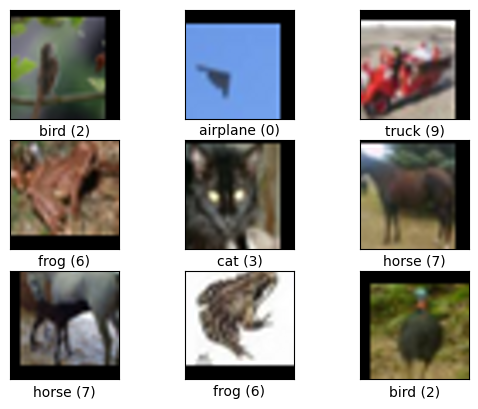

torch.Size([128, 3, 32, 32])


In [ ]:
# VISUALISE
# -----------------------

# Load data without normalisations

train_transform = transforms.Compose([
    # 4 pixels are padded on each side,
    transforms.Pad(4),
    # a 32×32 crop is randomly sampled from the
    # padded image or its horizontal flip.
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(32),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    # For testing, we only evaluate the single
    # view of the original 32×32 image.
    transforms.ToTensor()
])

train_loader, test_loader = get_data_loaders(data_dir,
                                             batch_size,
                                             train_transform,
                                             test_transform,
                                             shuffle=True,
                                             num_workers=4,
                                             pin_memory=True)


# Training images
data_iter = iter(train_loader)
images, labels = next(data_iter)
X = images.numpy().transpose([0, 2, 3, 1])
plot_images(X, labels)
print(images.shape)

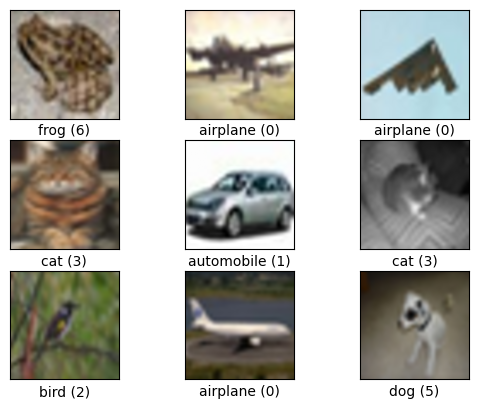

torch.Size([128, 3, 32, 32])


In [ ]:
# Test images
data_iter = iter(test_loader)
images, labels = next(data_iter)
X = images.numpy().transpose([0, 2, 3, 1])
plot_images(X, labels)
print(images.shape)

In [ ]:
# NORMALIZATION
# -----------------------
# Calculate the mean and standard deviation of each channel
# for all observations in training and test datasets. The
# results can then be used for normalisation

# Load data without transforms

train_transform = transforms.Compose([
    # 4 pixels are padded on each side,
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    # For testing, we only evaluate the single
    # view of the original 32×32 image.
    transforms.ToTensor()
])

train_loader, test_loader = get_data_loaders(data_dir,
                                             batch_size,
                                             train_transform,
                                             test_transform,
                                             shuffle=True,
                                             num_workers=4,
                                             pin_memory=True)


# Takes a while to run so I've hardcoded results below

means, stds = calculate_normalisation_params(train_loader, test_loader)
print(f'means: {means}')
print(f'stds: {stds}')

means: [np.float64(0.49186879012009005), np.float64(0.4918589465435146), np.float64(0.4918420299066876)]
stds: [np.float64(0.24697121702736025), np.float64(0.24696826851354747), np.float64(0.24697503554051625)]


In [ ]:
# SET FINAL TRANSFORMS WITH NORMALISATION

# [x] simple data augmentation in [24]
# [x] 4 pixels are padded on each side,
# [x] and a 32×32 crop is randomly sampled from the padded image or its horizontal flip.
# [x] For testing, we only evaluate the single view of the original 32×32 image.


# Normalisation parameters fo CIFAR10
means = [0.49186879012009005,0.4918589465435146,0.4918420299066876]
stds  = [0.24697121702736025, 0.24696826851354747,0.24697503554051625]

normalize = transforms.Normalize(
    mean=means,
    std=stds,
)

train_transform = transforms.Compose([
    # 4 pixels are padded on each side,
    transforms.Pad(4),
    # a 32×32 crop is randomly sampled from the
    # padded image or its horizontal flip.
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(32),
    transforms.ToTensor(),
    normalize
])

test_transform = transforms.Compose([
    # For testing, we only evaluate the single
    # view of the original 32×32 image.
    transforms.ToTensor(),
    normalize
])

In [ ]:
# How many iterations in an epoch?

iterations = 0
for i, data in enumerate(train_loader, 0):
    iterations +=1
print(iterations)

391


In [ ]:
# TRAINING PARAMETERS
# -------------------------
# 64000/391 = 164
epochs = 164

# OPTIMISER PARAMETERS
lr = 0.1
momentum = 0.9
weight_decay = 0.0001

# LEARNING RATE ADJUSTMENT
# Reduce learning rate at iterations
# 32k and 48k. Convert to epochs:
# e.g. iterations / (n_observations/batch_size)
# 32000/391 = 82
# 48000/391 = 123
milestones = [82, 123]
# Divide learning rate by 10 at each milestone
gamma = 0.1

## Plain nets

Run training loop for 'plain' convolutional networks without shortcuts. Here we run for n={3, 5, 7,9} corresponding to networks of depth 20, 32, 44 and 54 layers.

In [ ]:
# TRAIN PLAIN NETs

# n determines network size as described in paper
# where total number of layers is (6*n)+2
ns = [3, 5, 7, 9]

os.makedirs('results', exist_ok=True)
os.makedirs('pretrained', exist_ok=True)
for n in ns:
    print(f'MODEL SIZE: n={n}')
    train_loader, test_loader = get_data_loaders(data_dir,
                                                 batch_size,
                                                 train_transform,
                                                 test_transform,
                                                 shuffle=True,
                                                 num_workers=4,
                                                 pin_memory=True)

    model = ResNet(n, shortcuts=False)
    criterion = torch.nn.NLLLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=gamma)
    results_file = f'results/plainnet{6*n+2}.csv'
    model_file = f'pretrained/plainnet{6*n+2}.pt'
    train(model, epochs, train_loader, test_loader, criterion,
          optimizer, results_file, scheduler=scheduler, MODEL_PATH=model_file)

MODEL SIZE: n=3
cuda:0
Epoch 	Batch 	NLLLoss_Train


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipython-input-288/2956343897.py:31: FutureWarning: `nn.init.kaiming_normal` is now deprecated in favor of `nn.init.kaiming_normal_`.
  nn.init.kaiming_normal(m.weight)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow

1 	50 	2.121
1 	100 	1.908
1 	150 	1.813
1 	200 	1.745
1 	250 	1.672
1 	300 	1.668
1 	350 	1.626
train_err: 0.5971 test_err: 0.5728


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


2 	50 	1.568
2 	100 	1.557
2 	150 	1.502
2 	200 	1.496
2 	250 	1.443
2 	300 	1.430
2 	350 	1.371
train_err: 0.49866 test_err: 0.4826


...

131 	50 	0.054
131 	100 	0.059
131 	150 	0.052
131 	200 	0.057
131 	250 	0.059
131 	300 	0.052
131 	350 	0.055
train_err: 0.01492 test_err: 0.1023


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


132 	50 	0.055
132 	100 	0.053
132 	150 	0.045
132 	200 	0.055
132 	250 	0.052
132 	300 	0.058
132 	350 	0.054
train_err: 0.0139 test_err: 0.1027


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


133 	50 	0.059
133 	100 	0.055
133 	150 	0.053
133 	200 	0.057
133 	250 	0.049
133 	300 	0.055
133 	350 	0.056


## Residual nets

Run training loop for residual networks with shortcuts. Here we run for n={3, 5, 7,9} corresponding to networks of depth 20, 32, 44 and 64 layers.

In [ ]:
# TRAIN RESNETs

# n determines network size as described in paper
ns = [3, 5, 7, 9]

# Create results and pretrained directories if they don't exist
os.makedirs('results', exist_ok=True)
os.makedirs('pretrained', exist_ok=True)

# Train resnets
for n in ns:
    print(f'MODEL SIZE: n={n}')
    # Reload data
    train_loader, test_loader = get_data_loaders(data_dir,
                                                 batch_size,
                                                 train_transform,
                                                 test_transform,
                                                 shuffle=True,
                                                 num_workers=4,
                                                 pin_memory=True)

    model = ResNet(n, shortcuts=True)
    criterion = torch.nn.NLLLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=gamma)
    results_file = f'results/resnet{6*n+2}.csv'
    model_file = f'pretrained/resnet{6*n+2}.pt'
    train(model, epochs, train_loader, test_loader, criterion,
          optimizer, results_file, scheduler=scheduler, MODEL_PATH=model_file)

In [ ]:
print(f'Parameter count: {sum([p.numel() for p in model.parameters()])}')

In [ ]:
print(model)